# 🧠 Learning Neural Networks from Scratch

This notebook builds core neural network components **from scratch** using NumPy—inspired by the approach in *Neural Networks from Scratch* . We'll implement dense layers, activations (ReLU, Softmax), loss (categorical cross-entropy), and basic optimization.

**📚 References:**
- [Neural Networks from Scratch (NNFS) book](https://nnfs.io/)
- [NumPy documentation](https://numpy.org/doc/stable/)

---
## 1️⃣ NumPy basics: inputs, weights, and biases

Neural layers compute **output = inputs × weights + biases**. We'll use NumPy for fast array math. Here we set up a single "sample" with 4 inputs and 3 neurons (outputs).

**🔗** [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html)

In [2]:
import numpy as np

# One sample: 4 input features
inputs = [1.0, 2.0, 3.0, 2.5]
# 3 neurons, each with 4 weights (one per input)
weights = [
    [0.2, 0.8, -0.5, 1.0],
    [0.5, -0.91, 0.26, -0.5],
    [-0.26, -0.27, 0.17, 0.87],
]
biases = [2.0, 3.0, 0.5]

# Convert to NumPy arrays for matrix operations
i = np.array(inputs)
w = np.array(weights)
b = np.array(biases)

print("Weights shape:", w.shape)  # (3 neurons, 4 inputs)
print("Output (dot product + bias):", np.dot(i, w.T) + b)

Weights shape: (3, 4)
Output (dot product + bias): [4.8   1.21  2.385]


### 📐 Sum and max along axes

When we process **batches** of samples, we often sum or take the max along an axis (e.g. over neurons or over samples). `keepdims=True` keeps the result as a 2D array so broadcasting works cleanly.

In [3]:
# Sum over all elements
print("Sum over axis=0 (down columns):", np.sum(w, axis=0))
print("Sum over axis=1 (along rows):", np.sum(w, axis=1))
print("With keepdims=True (shape for broadcasting):", np.sum(w, axis=1, keepdims=True).shape)
print("Max over axis=0:", np.max(w, axis=0))
print("Max over axis=1:", np.max(w, axis=1))

Sum over axis=0 (down columns): [ 0.44 -0.38 -0.07  1.37]
Sum over axis=1 (along rows): [ 1.5  -0.65  0.51]
With keepdims=True (shape for broadcasting): (3, 1)
Max over axis=0: [0.5  0.8  0.26 1.  ]
Max over axis=1: [1.   0.5  0.87]


---
## 2️⃣ Dataset: spiral data

We need **non-linearly separable** data to see why we need hidden layers and activations. The NNFS-style **spiral dataset** is perfect: classes wind around the origin.

**Note:** The code below uses the `nnfs` package for data. If you don't have it, install with `pip install nnfs`, or we can define a simple spiral generator with NumPy only.

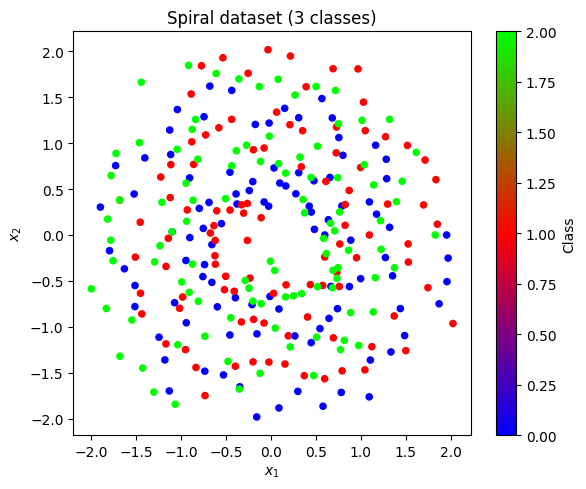

In [4]:
# Try to use nnfs.datasets; fallback to a simple spiral with NumPy
try:
    import nnfs
    from nnfs.datasets import spiral_data
    nnfs.init()
    X, y = spiral_data(samples=100, classes=3)
except ImportError:
    # Simple spiral-like data without nnfs
    np.random.seed(42)
    n = 100
    t = np.linspace(0, 4 * np.pi, n)
    X = np.zeros((n * 3, 2))
    y = np.zeros(n * 3, dtype=int)
    for c in range(3):
        r = np.linspace(0.5, 2, n) + 0.2 * np.random.randn(n)
        X[c * n:(c + 1) * n, 0] = r * np.cos(t + c * 2 * np.pi / 3)
        X[c * n:(c + 1) * n, 1] = r * np.sin(t + c * 2 * np.pi / 3)
        y[c * n:(c + 1) * n] = c

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="brg", s=20)
plt.title("Spiral dataset (3 classes)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.colorbar(label="Class")
plt.tight_layout()
plt.show()

---
## 3️⃣ Building blocks: Dense layer, ReLU, Softmax

We implement three core pieces:

| Component | Role |
|-----------|------|
| **Dense** | Linear transform: `output = inputs @ weights + biases` |
| **ReLU** | Non-linearity: `max(0, x)` — [Wikipedia: ReLU](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)) |
| **Softmax** | Turns logits into probabilities (for classification): [Softmax](https://en.wikipedia.org/wiki/Softmax_function) |

Numerical tip: we subtract the max before `exp` in Softmax to avoid overflow.

In [5]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.inputs = inputs  # store for backprop later
        self.output = np.dot(inputs, self.weights) + self.biases


class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)


class Activation_Softmax:
    def forward(self, inputs):
        # Subtract max for numerical stability
        exp_vals = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.output = exp_vals / np.sum(exp_vals, axis=1, keepdims=True)

---
## 4️⃣ Loss and accuracy

**Categorical cross-entropy** measures how wrong our class probabilities are. We **clip** predictions away from 0 and 1 to avoid $\log(0)$. For class indices (not one-hot), we pick the predicted probability of the true class and take $-\log(\text{that})$.

**🔗** [Cross-entropy (Wikipedia)](https://en.wikipedia.org/wiki/Cross-entropy)

In [6]:
class Loss:
    def calculate(self, output, y_true):
        sample_losses = self.forward(output, y_true)
        return np.mean(sample_losses)


class Loss_CategoricalCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        n_samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        if len(y_true.shape) == 1:
            correct_confidence = y_pred_clipped[range(n_samples), y_true]
        else:
            correct_confidence = np.sum(y_pred_clipped * y_true, axis=1)
        return -np.log(correct_confidence)

### 🔢 Accuracy

Accuracy = fraction of samples where the **predicted class** (argmax of probabilities) equals the true class.

In [7]:
def accuracy(y_pred_probs, y_true):
    """y_pred_probs: (n_samples, n_classes), y_true: (n_samples,) class indices."""
    predictions = np.argmax(y_pred_probs, axis=1)
    return np.mean(predictions == y_true)

---
## 5️⃣ Full forward pass and loss

We wire: **Dense(2 → 64) → ReLU → Dense(64 → 3) → Softmax**, then compute loss and accuracy on the spiral data.

In [8]:
# Build network: 2 inputs (spiral has 2 features), 64 hidden, 3 classes
dense1 = Layer_Dense(2, 64)
relu = Activation_ReLU()
dense2 = Layer_Dense(64, 3)
softmax = Activation_Softmax()
loss_fn = Loss_CategoricalCrossentropy()

# Forward pass
dense1.forward(X)
relu.forward(dense1.output)
dense2.forward(relu.output)
softmax.forward(dense2.output)

loss = loss_fn.calculate(softmax.output, y)
acc = accuracy(softmax.output, y)
print(f"Loss: {loss:.4f}  Accuracy: {acc:.4f}")

Loss: 1.0986  Accuracy: 0.3400


---
## 6️⃣ Optimization: random search

Before gradient descent, we can try **random search**: repeatedly sample new weights (or small updates) and keep them only if loss improves. It's inefficient but illustrates that we're optimizing parameters. Below we do a small number of steps; increase `n_steps` to see gradual improvement.

**🔗** [Optimization (Wikipedia)](https://en.wikipedia.org/wiki/Hyperparameter_optimization#Random_search)

In [9]:
best_loss = float("inf")
best_weights1 = dense1.weights.copy()
best_biases1 = dense1.biases.copy()
best_weights2 = dense2.weights.copy()
best_biases2 = dense2.biases.copy()
n_steps = 50000
scale = 0.05

for step in range(n_steps):
    dense1.weights = best_weights1 + scale * np.random.randn(*dense1.weights.shape)
    dense1.biases = best_biases1 + scale * np.random.randn(*dense1.biases.shape)
    dense2.weights = best_weights2 + scale * np.random.randn(*dense2.weights.shape)
    dense2.biases = best_biases2 + scale * np.random.randn(*dense2.biases.shape)

    #dense1.weights = scale * np.random.randn(*dense1.weights.shape)
    #dense1.biases =  scale * np.random.randn(*dense1.biases.shape)
    #dense2.weights = scale * np.random.randn(*dense2.weights.shape)
    #dense2.biases =  scale * np.random.randn(*dense2.biases.shape)


    
    dense1.forward(X)
    relu.forward(dense1.output)
    dense2.forward(relu.output)
    softmax.forward(dense2.output)
    loss = loss_fn.calculate(softmax.output, y)

    if loss < best_loss:
        best_loss = loss
        best_weights1 = dense1.weights.copy()
        best_biases1 = dense1.biases.copy()
        best_weights2 = dense2.weights.copy()
        best_biases2 = dense2.biases.copy()
        print(f"After {step} random-search steps — Loss: {loss_fn.calculate(softmax.output, y):.4f}  Accuracy: {accuracy(softmax.output, y):.4f}")
        
    # Restore best and report
    dense1.weights, dense1.biases = best_weights1, best_biases1
    dense2.weights, dense2.biases = best_weights2, best_biases2
    dense1.forward(X)
    relu.forward(dense1.output)   
    dense2.forward(relu.output)
    softmax.forward(dense2.output)


After 0 random-search steps — Loss: 1.0985  Accuracy: 0.3367
After 3 random-search steps — Loss: 1.0977  Accuracy: 0.3400
After 8 random-search steps — Loss: 1.0977  Accuracy: 0.3433
After 15 random-search steps — Loss: 1.0963  Accuracy: 0.3400
After 35 random-search steps — Loss: 1.0957  Accuracy: 0.3267
After 36 random-search steps — Loss: 1.0940  Accuracy: 0.3567
After 59 random-search steps — Loss: 1.0940  Accuracy: 0.3367
After 75 random-search steps — Loss: 1.0939  Accuracy: 0.3533
After 80 random-search steps — Loss: 1.0913  Accuracy: 0.3600
After 105 random-search steps — Loss: 1.0906  Accuracy: 0.3667
After 113 random-search steps — Loss: 1.0906  Accuracy: 0.3433
After 129 random-search steps — Loss: 1.0896  Accuracy: 0.3767
After 165 random-search steps — Loss: 1.0890  Accuracy: 0.3600
After 181 random-search steps — Loss: 1.0862  Accuracy: 0.3567
After 442 random-search steps — Loss: 1.0856  Accuracy: 0.3600
After 509 random-search steps — Loss: 1.0852  Accuracy: 0.3900
Afte

---
## 7️⃣ Backpropagation (concept and formulas)

**Backprop** computes how much each weight and bias contributed to the loss by applying the **chain rule**. For a dense layer $Y = XW + b$:

- **Gradient w.r.t. weights:** $\frac{\partial L}{\partial W} = X^\top \frac{\partial L}{\partial Y}$
- **Gradient w.r.t. biases:** $\frac{\partial L}{\partial b} = \sum \frac{\partial L}{\partial Y}$ (sum over batch)
- **Gradient w.r.t. inputs:** $\frac{\partial L}{\partial X} = \frac{\partial L}{\partial Y} \, W^\top$ (to pass gradient to previous layer)

For **ReLU**, the gradient is 1 where input > 0 and 0 where input ≤ 0.

**🔗** [Backpropagation (Wikipedia)](https://en.wikipedia.org/wiki/Backpropagation)

In [ ]:
# Illustrating the math (dvalues = dL/dY from the layer above)
inputs_demo = np.array([[1, 2], [3, 4]])  # batch of 2, 2 features
weights_demo = np.array([[0.5, 0.3], [0.2, 0.8]])
dvalues = np.array([[0.1, 0.2], [0.3, 0.4]])  # gradient from next layer

dweights = np.dot(inputs_demo.T, dvalues)
dbiases = np.sum(dvalues, axis=0, keepdims=True)
dinputs = np.dot(dvalues, weights_demo.T)
print("dweights shape:", dweights.shape)
print("dbiases shape:", dbiases.shape)
print("dinputs shape:", dinputs.shape)

### Adding `backward` methods to our classes

We can extend `Layer_Dense` and `Activation_ReLU` with `backward(dvalues)` so they store gradients and pass `dinputs` to the previous layer. Then an optimizer (e.g. SGD) would do `weights -= learning_rate * dweights`. Here we just add the backward logic.

In [ ]:
def dense_backward(self, dvalues):
    self.dweights = np.dot(self.inputs.T, dvalues)
    self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
    self.dinputs = np.dot(dvalues, self.weights.T)


def relu_backward(self, dvalues):
    self.dinputs = dvalues.copy()
    self.dinputs[self.inputs <= 0] = 0


# Attach to classes (could also be defined inside the class)
Layer_Dense.backward = dense_backward
Activation_ReLU.backward = relu_backward
print("Backward methods attached. Use: layer.backward(dvalues_from_next_layer)")

---
## 📌 Summary

| Topic | What we did |
|-------|--------------|
| **NumPy** | Inputs, weights, biases as arrays; `dot`, `sum`, `max` with axes |
| **Data** | Spiral (or fallback) 3-class dataset |
| **Layers** | `Layer_Dense`, `Activation_ReLU`, `Activation_Softmax` |
| **Loss** | `Loss_CategoricalCrossentropy` with clipping |
| **Optimization** | Random search over weights/biases |
| **Backprop** | Formulas and `backward()` for Dense and ReLU |

**Next steps:** Implement gradient descent (SGD) using the backward pass and update weights with `W -= lr * dW` each step. For full training loops and more, see the [NNFS book](https://nnfs.io/) and the [Learning_NNFS repo](https://github.com/siranguru/Learning_NNFS).

---
## 🚀 How to run this notebook

### Prerequisites

- **Python** 3.10 or 3.11 (recommended).
- **pip** (usually bundled with Python).

### 1. Create and activate a virtual environment

From the **repository root** (`LLMs-from-scratch/`):

```bash
cd /path/to/LLMs-from-scratch
python3 -m venv .venv
source .venv/bin/activate   # On Windows: .venv\Scripts\activate
```

### 2. Install dependencies

**Option A — Use the main book requirements (includes Jupyter, NumPy, Matplotlib):**

```bash
pip install -r requirements.txt
```

**Option B — Minimal install for this notebook only** (from `ch04/01_main-chapter-code/`):

```bash
cd ch04/01_main-chapter-code
pip install -r requirements-learning-nnfs.txt
```

### 3. Optional: NNFS spiral data

For the official spiral dataset (same as in the NNFS book), install:

```bash
pip install nnfs
```

If `nnfs` is not installed, the notebook uses a NumPy-only spiral fallback—no extra install needed.

### 4. Run the notebook

- **Jupyter:** `jupyter notebook Learning_neural_network_from_scratch.ipynb`  
  or `jupyter lab Learning_neural_network_from_scratch.ipynb`
- **VS Code / Cursor:** Open the `.ipynb` file and run cells with the play button or **Run All**.
- **Command line (run all cells):**  
  `jupyter nbconvert --to notebook --execute Learning_neural_network_from_scratch.ipynb --inplace`

Run cells **in order** from top to bottom; later cells depend on variables (e.g. `X`, `y`, `dense1`, `accuracy`) defined in earlier ones.